# Principal Component Analysis — Extensions

In the previous notebook we built standard (linear) PCA via the eigendecomposition of the $D \times D$ covariance matrix. That works well when the number of features $D$ is modest, but it runs into trouble in two common situations. This notebook implements two extensions that address them:

**This notebook covers:**
1. **High-dimensional PCA** — when the number of samples $N$ is *smaller* than the number of features $D$ (e.g. a handful of $784$-pixel images), eigendecomposing the $D \times D$ covariance is wasteful. We rewrite the computation in terms of a much smaller $N \times N$ matrix and compare the runtimes.
2. **Kernel PCA** — standard PCA can only capture *linear* structure. Using the **kernel trick**, kernel PCA performs PCA in an implicit nonlinear feature space, letting it separate data that linear PCA cannot (interleaving moons, concentric circles).

As before, we collect $N$ samples into a matrix $\mathbf{X} \in \mathbb{R}^{N \times D}$, where the $n$-th **row** is the sample $\mathbf{x}_n = (x_{n1}, \dots, x_{nD})^\mathrm{T}$.

## Imports and the Linear PCA Baseline

We reuse the linear `PCA` class from the previous notebook as a baseline to compare against. `HighDimPCA` below will *inherit* from it, so we only have to re-implement the parts that change.

In [74]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles, fetch_openml

In [75]:
# Linear PCA from the previous notebook, used here as a baseline.
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        X = np.array(X)
        N, D = X.shape
        self.mu_ = np.mean(X, axis=0)
        # D x D covariance matrix.
        S = ((X - self.mu_).T @ (X - self.mu_)) / N
        self.lmbdas_, self.U_ = np.linalg.eigh(S)
        sort_idx = np.argsort(-self.lmbdas_)
        self.lmbdas_ = self.lmbdas_[sort_idx]
        self.U_ = self.U_[:, sort_idx]
        self._determine_M()
        return self

    def transform(self, X):
        B = self.U_[:, :self.M_]
        X = np.array(X)
        Z = (X - self.mu_) @ B
        return Z

    def inverse_transform(self, Z):
        B = self.U_[:, :self.M_]
        Z = np.array(Z)
        X = Z @ B.T
        X += self.mu_
        return X

    def _determine_M(self):
        if self.n_components >= 1:
            self.M_ = self.n_components
        elif 0 < self.n_components < 1:
            cum_lmbdas = np.cumsum(self.lmbdas_ / np.sum(self.lmbdas_))
            self.M_ = np.argmax(cum_lmbdas >= self.n_components) + 1
        else:
            raise ValueError('Invalid `n_components` parameter.')

## High-Dimensional PCA

Linear PCA eigendecomposes the $D \times D$ covariance matrix $\mathbf{S} = \frac{1}{N}\mathbf{X}_c^\mathrm{T}\mathbf{X}_c$, where $\mathbf{X}_c = \mathbf{X} - \boldsymbol{\mu}$ is the centered data. This costs $\mathcal{O}(D^3)$ — fine for small $D$, but wasteful when $D \gg N$ (for example $N = 20$ images with $D = 784$ pixels each).

The key observation: a covariance matrix built from only $N$ samples has **at most $N$ nonzero eigenvalues**, so almost all of that $\mathcal{O}(D^3)$ work goes into zero directions. We can recover the useful eigenvectors from a much smaller $N \times N$ matrix instead.

Define $\;\mathbf{C} = \frac{1}{N}\mathbf{X}_c\mathbf{X}_c^\mathrm{T} \in \mathbb{R}^{N \times N}$. If $\mathbf{v}$ is an eigenvector of $\mathbf{C}$ with eigenvalue $\delta$, then left-multiplying $\mathbf{C}\mathbf{v} = \delta\mathbf{v}$ by $\mathbf{X}_c^\mathrm{T}$ gives
$$\underbrace{\tfrac{1}{N}\mathbf{X}_c^\mathrm{T}\mathbf{X}_c}_{\mathbf{S}}\,(\mathbf{X}_c^\mathrm{T}\mathbf{v}) = \delta\,(\mathbf{X}_c^\mathrm{T}\mathbf{v}).$$
So $\mathbf{X}_c^\mathrm{T}\mathbf{v}$ is an eigenvector of $\mathbf{S}$ with the **same eigenvalue** $\delta$. This gives the recipe:

1. Eigendecompose the small matrix $\mathbf{C}$ ($N \times N$) to get eigenvalues $\delta_i$ and eigenvectors $\mathbf{v}_i$.
2. The nonzero eigenvalues of $\mathbf{S}$ are exactly these $\delta_i$ (the remaining $D - N$ are zero).
3. The corresponding eigenvectors of $\mathbf{S}$ are $\mathbf{u}_i = \mathbf{X}_c^\mathrm{T}\mathbf{v}_i$, **normalized** to unit length.
4. Sort by decreasing eigenvalue, as before.

> **Implement the `HighDimPCA` class below.** Because it inherits from `PCA`, it only needs to override `fit` — `transform`, `inverse_transform`, and `_determine_M` are reused unchanged.

**Python note — normalization:** the vectors $\mathbf{X}_c^\mathrm{T}\mathbf{v}_i$ are eigenvectors of $\mathbf{S}$ but are *not* unit length, so we divide each column by its norm (`np.linalg.norm(..., axis=0)`). This matters because `transform`/`inverse_transform` assume orthonormal columns.

**Python note — zero-padding:** `self.lmbdas_` is allocated with length $D$ but only its first $N$ entries are filled with the $\delta_i$; the rest stay zero, representing the directions with no variance.

In [76]:
# Load MNIST and pick a small subset, so that N (= 20) is much smaller than D (= 784).
X_img_all, y_img_all = fetch_openml('mnist_784', version=1, return_X_y=True)

np.random.seed(0)
idx = np.random.choice(range(len(X_img_all)), replace=False, size=20)
X_img = X_img_all.values[idx]
y_img = y_img_all.values[idx]

In [77]:
class HighDimPCA(PCA):
    """Principal component analysis for N < D, where N is the number of
    samples and D is the number of features.
    """
    def fit(self, X):
        """Determine the parameters of the PCA using the N x N covariance trick.

        Args:
            X (array-like): Input samples.

        Returns:
            The fitted PCA object.
        """
        X = np.array(X)
        N, D = X.shape
        self.mu_ = np.mean(X, axis=0)
        C = ((X - self.mu_) @ (X - self.mu_).T) / N
        self.lmbdas_, V = np.linalg.eigh(C)
        u = (X - self.mu_).T @ V
        self.U_ = u / np.linalg.norm(u, axis=0)
        sort_idx = np.argsort(-self.lmbdas_)
        self.lmbdas_ = self.lmbdas_[sort_idx]
        self.U_ = self.U_[:, sort_idx]
        self._determine_M()
        return self
####################
# Your Code Here   #
####################

> **Compare the runtime** of `HighDimPCA` against the vanilla `PCA` using the `%timeit` magic.

**Python note — `%timeit`:** Jupyter's `%timeit` line magic runs a statement many times and reports the average runtime — handy for quick benchmarks. The cell below shows the syntax on a trivial example.

In [78]:
# Example usage of the %timeit magic.
%timeit np.dot(5, 5)

364 ns ± 4.27 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [79]:
####################
# Your Code Here   #
####################
%timeit PCA(n_components=2).fit(X_img)
%timeit HighDimPCA(n_components=2).fit(X_img)

20.6 ms ± 269 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
108 μs ± 5.92 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


**What to look for:** `HighDimPCA` should be dramatically faster (often ~100x). The vanilla version eigendecomposes a $784 \times 784$ matrix, while `HighDimPCA` only touches a $20 \times 20$ one — yet both yield the same leading principal components, because they share the same nonzero eigenvalues and eigenvectors.

## Kernel PCA

Standard PCA can only find **linear** subspaces, so it fails when the interesting structure is nonlinear — such as two interleaving moons or concentric circles, where no straight projection separates the classes.

**Kernel PCA** fixes this with the *kernel trick*. Conceptually, we map each sample into a high-dimensional feature space $\phi(\mathbf{x})$ where the structure becomes linearly separable, and run PCA there. The trick is that we never form $\phi(\mathbf{x})$ explicitly — every computation only needs **inner products** $\phi(\mathbf{x})^\mathrm{T}\phi(\mathbf{x}')$, which a **kernel function**
$$k(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^\mathrm{T}\phi(\mathbf{x}')$$
provides directly, without ever computing $\phi$.

> First, let's generate the two nonlinear toy data sets and look at them.

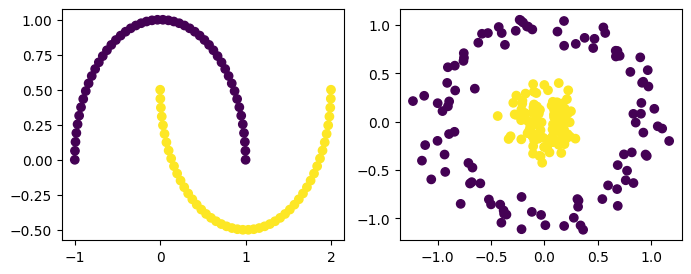

In [80]:
X_moons, y_moons = make_moons(n_samples=100, random_state=0)
X_circles, y_circles = make_circles(n_samples=200, factor=.2, noise=.1, random_state=0)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.subplot(122)
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles)
plt.show()

> **Apply standard (linear) PCA** to both data sets — reduce to one component and reconstruct — and observe why it cannot separate the classes.

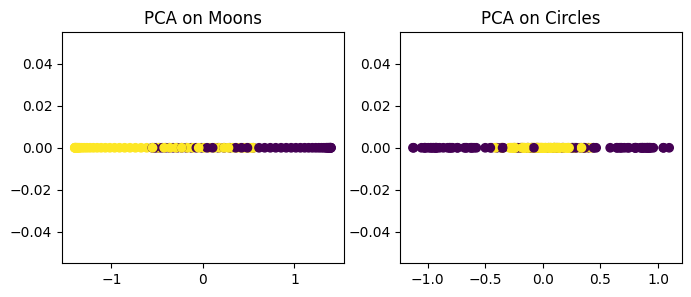

In [81]:
####################
# Your Code Here   #
####################
pca_moons = PCA(n_components=1).fit(X_moons)
pca_circles = PCA(n_components=1).fit(X_circles)

pca_moons_1d = pca_moons.transform(X_moons)
pca_circles_1d = pca_circles.transform(X_circles)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.scatter(pca_moons_1d, np.zeros_like(pca_moons_1d), c=y_moons)
plt.title('PCA on Moons')
plt.subplot(122)
plt.scatter(pca_circles_1d, np.zeros_like(pca_circles_1d), c=y_circles)
plt.title('PCA on Circles')
plt.show()

> **Implement the Gaussian (RBF) kernel**
$$k_\sigma(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\lVert \mathbf{x} - \mathbf{x}'\rVert^2 / \sigma\right).$$

In [82]:
class GaussianKernel:
    def __init__(self, sigma):
####################
# Your Code Here   #
####################
        self.sigma = sigma

    def __call__(self, x, y):
####################
# Your Code Here   #
####################
        return np.exp(-np.linalg.norm(x - y) ** 2 / (self.sigma))

Kernel PCA mirrors linear PCA, but replaces the covariance matrix with the **Gram (kernel) matrix** $\mathbf{K} \in \mathbb{R}^{N \times N}$, where $K_{nm} = k(\mathbf{x}_n, \mathbf{x}_m)$:

1. **Gram matrix:** compute $\mathbf{K}$ over all training pairs.
2. **Center in feature space:** we cannot subtract the mean of $\phi$ directly (we never see $\phi$), but the equivalent operation can be carried out on $\mathbf{K}$:
$$\tilde{\mathbf{K}} = \mathbf{K} - \mathbf{1}_N\mathbf{K} - \mathbf{K}\mathbf{1}_N + \mathbf{1}_N\mathbf{K}\mathbf{1}_N,$$
where $\mathbf{1}_N$ is the $N \times N$ matrix with every entry equal to $1/N$.

3. **Eigendecomposition:** eigendecompose $\tilde{\mathbf{K}}$ to get the expansion coefficients $\mathbf{a}_i$ (eigenvectors) and eigenvalues, sorted in decreasing order.
4. **Projection:** the projection of a point onto the top components is its centered kernel row multiplied by the leading eigenvectors.

> **Implement the `KernelPCA` class below.**

In [83]:
from sklearn.base import BaseEstimator

class KernelPCA(BaseEstimator):
    """Kernel principal component analysis.

    Args:
        n_components (int): Number of components to keep.
        kernel_func: Kernel function k(x, y) used to build the Gram matrix.
    """
    def __init__(self, n_components, kernel_func=GaussianKernel, sigma=0.5):
        self.n_components = n_components
        self.kernel_func = kernel_func
        self.sigma = sigma

    def fit(self, X, y=None):
        """Determine the parameters of the kernel PCA.

        Args:
            X (array-like): Input samples.

        Returns:
            The fitted PCA object.
        """
####################
# Your Code Here   #
####################
        X = np.array(X)
        self.X_train = X
        self.kernel_ = self.kernel_func(self.sigma) if isinstance(self.kernel_func, type) else self.kernel_func
        K = self.get_gram_matrix(X)
        self.K_fit_col_mean_ = np.mean(K, axis=0, keepdims=True)
        self.K_fit_all_mean_ = np.mean(K)
        K_centered = self.center_gram_matrix(K)

        eigenvals, eigenvecs = np.linalg.eigh(K_centered)
        sort_idx = np.argsort(eigenvals)[::-1]
        self.eigenvals = eigenvals[sort_idx]
        self.eigenvecs = eigenvecs[:, sort_idx]

        eps = np.finfo(float).eps
        scales = np.sqrt(np.maximum(self.eigenvals[:self.n_components], eps))
        self.alphas_ = self.eigenvecs[:, :self.n_components] / scales
        return self

    def get_gram_matrix(self, X1, X2=None):
        """Compute the Gram matrix of kernel values.

        Args:
            X1 (ndarray): Samples in the input space.
            X2 (ndarray): Optional second set of samples (defaults to X1).

        Returns:
            The Gram matrix for all sample pairs.
        """
####################
# Your Code Here   #
####################
        X1 = np.array(X1)
        if X2 is None:
            X2 = X1
        else:
            X2 = np.array(X2)
        N1, N2 = X1.shape[0], X2.shape[0]
        K = np.zeros((N1, N2))
        for i in range(N1):
            for j in range(N2):
                K[i, j] = self.kernel_(X1[i], X2[j])
        return K

    def center_gram_matrix(self, K):
        """Center the Gram matrix, i.e. center the features in the feature space.

        Args:
            K (ndarray): Gram matrix computed by the kernel.

        Returns:
            The centered Gram matrix (zero mean in the feature space).
        """
####################
# Your Code Here   #
####################
        return K - np.mean(K, axis=0, keepdims=True) - np.mean(K, axis=1, keepdims=True) + np.mean(K)

    def transform(self, X):
        """Project samples from the input space onto the top principal components.

        Args:
            X (ndarray): Samples in the input space.

        Returns:
            Transformed samples in the projection space.
        """
####################
# Your Code Here   #
####################
        X = np.array(X)
        K = self.get_gram_matrix(X, self.X_train)
        K_centered = K - np.mean(K, axis=1, keepdims=True) - self.K_fit_col_mean_ + self.K_fit_all_mean_
        Z = K_centered @ self.alphas_
        return Z

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

    def score(self, X, y=None):
        if y is None:
            raise ValueError('KernelPCA.score needs labels for silhouette scoring.')
        from sklearn.metrics import silhouette_score
        return silhouette_score(self.transform(X), y)

> **Apply the kernel PCA to the toy data sets** and plot the data projected onto the first two principal components.

**What to look for:** in the projection space the two classes (colors) should become **clearly separated** — even linearly separable along a single axis — which the linear PCA above could not achieve. Try changing $\sigma$ to see how sensitive the result is.

In [84]:
####################
# Your Code Here   #
####################
kernel_pca = KernelPCA(n_components=1, sigma=0.5).fit(X_moons)

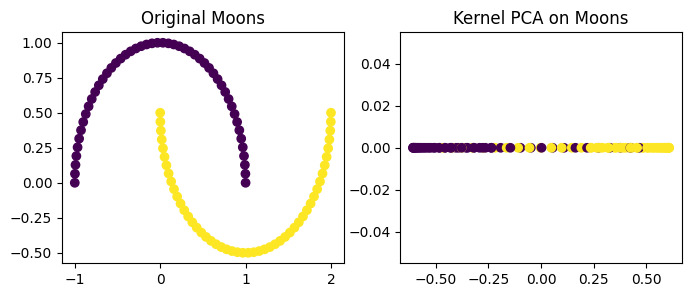

In [85]:
####################
# Your Code Here   #
####################
kernel_pca_moons_1d = kernel_pca.transform(X_moons).ravel()

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.title('Original Moons')
plt.subplot(122)
plt.scatter(kernel_pca_moons_1d, np.zeros_like(kernel_pca_moons_1d), c=y_moons)
plt.title('Kernel PCA on Moons')
plt.show()

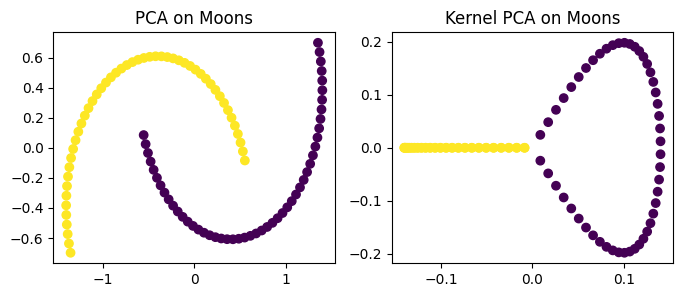

Silhouette Score - PCA: 0.316148238855915
Silhouette Score - Kernel PCA: 0.4818442370621792
Best sigma: 0.1
Best silhouette score: 0.3415325192304231


In [86]:
# difference between normal and kernel pca
kernel_pca = KernelPCA(n_components=2, sigma=0.0005).fit(X_moons)
pca = PCA(n_components=2).fit(X_moons)

kernel_pca_moons_2d = kernel_pca.transform(X_moons)
pca_moons_2d = pca.transform(X_moons)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.scatter(pca_moons_2d[:, 0], pca_moons_2d[:, 1], c=y_moons)
plt.title('PCA on Moons')
plt.subplot(122)
plt.scatter(kernel_pca_moons_2d[:, 0], kernel_pca_moons_2d[:, 1], c=y_moons)
plt.title('Kernel PCA on Moons')
plt.show()

# score seperation of both
from sklearn.metrics import silhouette_score

silhouette_pca = silhouette_score(pca_moons_2d, y_moons)
silhouette_kernel_pca = silhouette_score(kernel_pca_moons_2d, y_moons)

print(f"Silhouette Score - PCA: {silhouette_pca}")
print(f"Silhouette Score - Kernel PCA: {silhouette_kernel_pca}")

# search best kernel hyperparameter
from sklearn.model_selection import GridSearchCV

param_grid = {'sigma': [0.0005, 0.001, 0.01, 0.1, 0.5, 1, 5, 10]}
grid_search = GridSearchCV(KernelPCA(n_components=2), param_grid, cv=5)
grid_search.fit(X_moons, y_moons)

print(f"Best sigma: {grid_search.best_params_['sigma']}")
print(f"Best silhouette score: {grid_search.best_score_}")

#### Discussion questions

1. Why does standard PCA fail to separate the moons and circles data sets?
Because the data is non linearly seperable, PCA can only find linear subspaces, so it fails to capture the underlying structure of the data.

2. What role does the kernel parameter $\sigma$ play?
It controls the width of the Gaussian kernel, which affects how much influence each data point has on its neighbors.

3. Why do we use the kernel trick instead of mapping the data into the feature space explicitly?
Because the feature space can be very high dimensional or even infinite dimensional, making it computationally expensive or impossible to compute the mapping explicitly.